In [38]:
from __future__ import annotations

import itertools
from dataclasses import dataclass, field
from typing import Dict, FrozenSet, Hashable, List, Optional, Set, Tuple

import networkx as nx


# ============================================================
# Basic data structures
# ============================================================

Node = Hashable


@dataclass(frozen=True)
class Split:
    """
    A bipartition (A, B) of V(G). We store it canonically by normalized().
    """
    A: FrozenSet[Node]
    B: FrozenSet[Node]

    def normalized(self) -> "Split":
        a_key = (len(self.A), tuple(sorted(map(str, self.A))))
        b_key = (len(self.B), tuple(sorted(map(str, self.B))))
        return self if a_key <= b_key else Split(self.B, self.A)


@dataclass(frozen=True)
class TempSplitNode:
    """
    Temporary split-node used during recursive construction before quotient IDs
    are finalized.
    """
    token: int

    def __str__(self) -> str:
        return f"tmp_s{self.token}"

    def __repr__(self) -> str:
        return str(self)


@dataclass(frozen=True)
class SplitNode:
    """
    Final split-node label: s_owner^partner
    """
    owner_qid: int
    partner_qid: int

    def __str__(self) -> str:
        return f"s_{self.owner_qid}^{self.partner_qid}"

    def __repr__(self) -> str:
        return str(self)


@dataclass
class QuotientGraph:
    qid: int
    graph: nx.Graph
    graph_type: Optional[str] = None

    def split_nodes(self) -> List[SplitNode]:
        return [v for v in self.graph.nodes if isinstance(v, SplitNode)]

    def original_nodes(self) -> List[Node]:
        return [v for v in self.graph.nodes if not isinstance(v, (SplitNode, TempSplitNode))]


@dataclass
class QASST:
    """
    Quotient-Augmented Strong Split Tree.

    - quotients[qid] = quotient graph Q_qid
    - tree_edges = edges of the tree between quotient graphs
    - split_node_pairs[{qid1, qid2}] = the corresponding pair of split-nodes
    """
    quotients: Dict[int, QuotientGraph] = field(default_factory=dict)
    tree_edges: Set[FrozenSet[int]] = field(default_factory=set)
    split_node_pairs: Dict[FrozenSet[int], Tuple[SplitNode, SplitNode]] = field(default_factory=dict)

    def add_tree_edge(self, q1: int, q2: int, s1: SplitNode, s2: SplitNode) -> None:
        e = frozenset({q1, q2})
        self.tree_edges.add(e)
        self.split_node_pairs[e] = (s1, s2)


@dataclass
class PartialBuild:
    qasst: QASST


# ============================================================
# Split utilities
# ============================================================

def normalize_split(A: Set[Node], B: Set[Node]) -> Split:
    return Split(frozenset(A), frozenset(B)).normalized()


def frontier_sets(G: nx.Graph, A: Set[Node]) -> Tuple[Set[Node], Set[Node]]:
    """
    For a partition (A, B), return
      A1 = vertices in A that have at least one neighbor in B
      B1 = vertices in B that have at least one neighbor in A
    """
    V = set(G.nodes)
    A = set(A)
    B = V - A

    A1 = {a for a in A if any(G.has_edge(a, b) for b in B)}
    B1 = {b for b in B if any(G.has_edge(a, b) for a in A)}
    return A1, B1


def is_split_cut(G: nx.Graph, A: Set[Node]) -> bool:
    """
    Exact split test from the definition.

    (A, B) is a split iff the crossing edges form a complete bipartite graph
    between frontier subsets A1 ⊆ A and B1 ⊆ B.
    """
    V = set(G.nodes)
    A = set(A)
    B = V - A

    if not A or not B:
        return False

    A1, B1 = frontier_sets(G, A)

    # It is enough to verify the A-side:
    # every a in A either sees exactly B1, or sees nothing in B.
    for a in A:
        nbrs_in_B = {b for b in G.neighbors(a) if b in B}
        if a in A1:
            if nbrs_in_B != B1:
                return False
        else:
            if nbrs_in_B:
                return False

    return True


def all_splits(G: nx.Graph, nontrivial_only: bool = False) -> List[Split]:
    """
    Enumerate all splits exactly, by brute force over bipartitions.

    To avoid counting (A,B) and (B,A) twice, we fix one root vertex to always lie in A.
    """
    nodes = list(G.nodes)
    if len(nodes) < 2:
        return []

    root = nodes[0]
    rest = nodes[1:]
    V = set(nodes)

    out: List[Split] = []
    seen: Set[Split] = set()

    for r in range(len(rest) + 1):
        for subset in itertools.combinations(rest, r):
            A = {root, *subset}
            B = V - A

            if not B:
                continue

            if nontrivial_only and (len(A) == 1 or len(B) == 1):
                continue

            if is_split_cut(G, A):
                s = normalize_split(A, B)
                if s not in seen:
                    seen.add(s)
                    out.append(s)

    return out


def splits_cross(s1: Split, s2: Split) -> bool:
    """
    Two splits cross iff all four intersections are non-empty.
    """
    A, B = set(s1.A), set(s1.B)
    C, D = set(s2.A), set(s2.B)

    return bool(A & C) and bool(A & D) and bool(B & C) and bool(B & D)


def strong_splits(G: nx.Graph, nontrivial_only: bool = False) -> List[Split]:
    """
    Exact strong split extraction: a split is strong iff it crosses no other split.
    """
    splits = all_splits(G, nontrivial_only=nontrivial_only)
    out: List[Split] = []

    for i, s in enumerate(splits):
        if all(i == j or not splits_cross(s, t) for j, t in enumerate(splits)):
            out.append(s)

    return out


def split_sort_key(s: Split):
    """
    Stable deterministic ordering for reproducible recursive decomposition.
    """
    a = tuple(sorted(map(str, s.A)))
    b = tuple(sorted(map(str, s.B)))
    return (min(len(s.A), len(s.B)), a, b)


# ============================================================
# Collapse / quotient utilities
# ============================================================

def collapse_along_split(
    G: nx.Graph,
    split: Split,
    left_split_node,
    right_split_node,
) -> Tuple[nx.Graph, nx.Graph]:
    """
    Collapse the crossing complete-bipartite subgraph of a split into
    a pair of split-nodes, one on each side.
    """
    A, B = set(split.A), set(split.B)
    A1, B1 = frontier_sets(G, A)

    GA = G.subgraph(A).copy()
    GB = G.subgraph(B).copy()

    GA.add_node(left_split_node)
    for a in A1:
        GA.add_edge(left_split_node, a)

    GB.add_node(right_split_node)
    for b in B1:
        GB.add_edge(right_split_node, b)

    return GA, GB


def quotient_type(Q: nx.Graph) -> str:
    """
    Classify a quotient graph as clique / star / prime (plus trivial/empty helpers).
    """
    n = Q.number_of_nodes()

    if n == 0:
        return "empty"
    if n == 1:
        return "trivial"

    degs = sorted(dict(Q.degree()).values())

    # clique
    if all(d == n - 1 for d in degs):
        return "clique"

    # star
    if degs.count(1) == n - 1 and degs.count(n - 1) == 1:
        return "star"

    return "prime"


def relabel_node_in_graph(G: nx.Graph, old_node, new_node) -> None:
    if old_node != new_node:
        nx.relabel_nodes(G, {old_node: new_node}, copy=False)


def merge_qasst(base: QASST, other: QASST) -> None:
    overlap = set(base.quotients) & set(other.quotients)
    if overlap:
        raise ValueError(f"Overlapping quotient IDs: {overlap}")

    base.quotients.update(other.quotients)
    base.tree_edges |= other.tree_edges
    base.split_node_pairs.update(other.split_node_pairs)


def find_owner_quotient(qasst: QASST, node) -> Optional[int]:
    for qid, quotient in qasst.quotients.items():
        if node in quotient.graph.nodes:
            return qid
    return None


# ============================================================
# Main builder
# ============================================================

class QASSTBuilder:
    """
    Exact but simple builder.

    Notes:
      - This implementation assumes G is connected.
      - It uses brute-force split enumeration, so it is exponential in |V|.
      - The emphasis is correctness and clarity, not asymptotic optimality.
    """

    def __init__(self):
        self.next_qid = 1
        self.next_token = 1

    def fresh_qid(self) -> int:
        qid = self.next_qid
        self.next_qid += 1
        return qid

    def fresh_token(self) -> int:
        token = self.next_token
        self.next_token += 1
        return token

    def _base_case(self, G: nx.Graph) -> PartialBuild:
        qid = self.fresh_qid()
        quotient = QuotientGraph(
            qid=qid,
            graph=G.copy(),
            graph_type=quotient_type(G),
        )
        qasst = QASST(quotients={qid: quotient})
        return PartialBuild(qasst=qasst)

    def _choose_split(self, G: nx.Graph) -> Optional[Split]:
        ss = strong_splits(G, nontrivial_only=True)
        if not ss:
            return None
        ss.sort(key=split_sort_key)
        return ss[0]

    def _build(self, G: nx.Graph) -> PartialBuild:
        split = self._choose_split(G)
        if split is None:
            return self._base_case(G)

        left_temp = TempSplitNode(self.fresh_token())
        right_temp = TempSplitNode(self.fresh_token())

        GL, GR = collapse_along_split(G, split, left_temp, right_temp)

        left_part = self._build(GL)
        right_part = self._build(GR)

        qasst = left_part.qasst
        merge_qasst(qasst, right_part.qasst)

        left_qid = find_owner_quotient(qasst, left_temp)
        right_qid = find_owner_quotient(qasst, right_temp)

        if left_qid is None or right_qid is None:
            raise RuntimeError("Temporary split-node was lost during recursive construction.")

        left_final = SplitNode(owner_qid=left_qid, partner_qid=right_qid)
        right_final = SplitNode(owner_qid=right_qid, partner_qid=left_qid)

        relabel_node_in_graph(qasst.quotients[left_qid].graph, left_temp, left_final)
        relabel_node_in_graph(qasst.quotients[right_qid].graph, right_temp, right_final)

        qasst.quotients[left_qid].graph_type = quotient_type(qasst.quotients[left_qid].graph)
        qasst.quotients[right_qid].graph_type = quotient_type(qasst.quotients[right_qid].graph)

        qasst.add_tree_edge(left_qid, right_qid, left_final, right_final)

        return PartialBuild(qasst=qasst)

    def build(self, G: nx.Graph) -> QASST:
        if not nx.is_connected(G):
            raise ValueError("This implementation currently assumes a connected graph.")
        return self._build(G).qasst


def build_qasst(G: nx.Graph) -> QASST:
    return QASSTBuilder().build(G)


# ============================================================
# Reconstruction from QASST
# ============================================================

def qasst_to_global_graph(qasst: QASST) -> nx.Graph:
    """
    Compose all quotient graphs, then add the 'red edges' connecting split-node pairs.
    """
    H = nx.Graph()

    for quotient in qasst.quotients.values():
        H = nx.compose(H, quotient.graph)

    for _, (s1, s2) in qasst.split_node_pairs.items():
        H.add_edge(s1, s2)

    return H


def merge_one_split_pair(global_graph: nx.Graph, s, t) -> None:
    """
    Reverse one collapse step:
      remove split-nodes s,t and fully connect their respective neighbors.
    """
    Ns = set(global_graph.neighbors(s)) - {t}
    Nt = set(global_graph.neighbors(t)) - {s}

    for u in Ns:
        for v in Nt:
            if u != v:
                global_graph.add_edge(u, v)

    global_graph.remove_node(s)
    global_graph.remove_node(t)


def reconstruct_from_qasst(qasst: QASST) -> nx.Graph:
    """
    Reconstruct the original graph by iteratively merging split-node pairs.
    """
    H = qasst_to_global_graph(qasst)

    for _, (s1, s2) in list(qasst.split_node_pairs.items()):
        if s1 in H.nodes and s2 in H.nodes:
            merge_one_split_pair(H, s1, s2)

    out = nx.Graph()
    original_nodes = [v for v in H.nodes if not isinstance(v, (SplitNode, TempSplitNode))]
    out.add_nodes_from(original_nodes)

    for u, v in H.edges:
        if u in out.nodes and v in out.nodes:
            out.add_edge(u, v)

    return out


# ============================================================
# Validation / pretty-print
# ============================================================

def validate_qasst_no_internal_strong_splits(qasst: QASST) -> None:
    for qid, quotient in qasst.quotients.items():
        ss = strong_splits(quotient.graph, nontrivial_only=True)
        if ss:
            raise AssertionError(
                f"Quotient Q{qid} still has nontrivial strong splits: {ss}"
            )


def validate_reconstruction(G: nx.Graph, qasst: QASST) -> None:
    R = reconstruct_from_qasst(qasst)

    if set(G.nodes) != set(R.nodes):
        raise AssertionError("Node sets differ between G and reconstructed graph.")

    E1 = {frozenset(e) for e in G.edges}
    E2 = {frozenset(e) for e in R.edges}
    if E1 != E2:
        raise AssertionError("Edge sets differ between G and reconstructed graph.")


def validate_qasst(G: nx.Graph, qasst: QASST) -> None:
    validate_qasst_no_internal_strong_splits(qasst)
    validate_reconstruction(G, qasst)


def print_qasst_summary(qasst: QASST) -> None:
    print("Quotient graphs:")
    for qid, q in sorted(qasst.quotients.items()):
        print(f"  Q{qid}: type={q.graph_type}")
        print(f"    nodes: {list(q.graph.nodes)}")
        print(f"    edges: {list(q.graph.edges)}")

    print("Tree edges:")
    for e in sorted(qasst.tree_edges, key=lambda x: tuple(sorted(x))):
        q1, q2 = sorted(e)
        s1, s2 = qasst.split_node_pairs[e]
        print(f"  Q{q1} -- Q{q2} via {s1} <-> {s2}")


# ============================================================
# Sample runs
# ============================================================

if __name__ == "__main__":
    # 1) Path graph on 4 vertices
    G1 = nx.path_graph(4)
    q1 = build_qasst(G1)
    print("=== Example 1: P4 ===")
    print_qasst_summary(q1)
    validate_qasst(G1, q1)
    print("Reconstruction OK:", nx.is_isomorphic(G1, reconstruct_from_qasst(q1)))
    print()

    # 2) Cycle graph on 4 vertices
    G2 = nx.cycle_graph(4)
    q2 = build_qasst(G2)
    print("=== Example 2: C4 ===")
    print_qasst_summary(q2)
    validate_qasst(G2, q2)
    print("Reconstruction OK:", nx.is_isomorphic(G2, reconstruct_from_qasst(q2)))
    print()

    # 3) Complete graph on 4 vertices
    G3 = nx.complete_graph(4)
    q3 = build_qasst(G3)
    print("=== Example 3: K4 ===")
    print_qasst_summary(q3)
    validate_qasst(G3, q3)
    print("Reconstruction OK:", nx.is_isomorphic(G3, reconstruct_from_qasst(q3)))
    print()

    # 4) Star graph K1,4
    G4 = nx.star_graph(4)  # center 0, leaves 1..4
    q4 = build_qasst(G4)
    print("=== Example 4: Star K1,4 ===")
    print_qasst_summary(q4)
    validate_qasst(G4, q4)
    print("Reconstruction OK:", nx.is_isomorphic(G4, reconstruct_from_qasst(q4)))
    print()

=== Example 1: P4 ===
Quotient graphs:
  Q1: type=star
    nodes: [0, 1, s_1^2]
    edges: [(0, 1), (1, s_1^2)]
  Q2: type=star
    nodes: [2, 3, s_2^1]
    edges: [(2, 3), (2, s_2^1)]
Tree edges:
  Q1 -- Q2 via s_1^2 <-> s_2^1
Reconstruction OK: True

=== Example 2: C4 ===
Quotient graphs:
  Q1: type=star
    nodes: [0, 2, s_1^2]
    edges: [(0, s_1^2), (2, s_1^2)]
  Q2: type=star
    nodes: [1, 3, s_2^1]
    edges: [(1, s_2^1), (3, s_2^1)]
Tree edges:
  Q1 -- Q2 via s_1^2 <-> s_2^1
Reconstruction OK: True

=== Example 3: K4 ===
Quotient graphs:
  Q1: type=clique
    nodes: [0, 1, 2, 3]
    edges: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
Tree edges:
Reconstruction OK: True

=== Example 4: Star K1,4 ===
Quotient graphs:
  Q1: type=star
    nodes: [0, 1, 2, 3, 4]
    edges: [(0, 1), (0, 2), (0, 3), (0, 4)]
Tree edges:
Reconstruction OK: True



In [39]:
from __future__ import annotations

import itertools
import math
from dataclasses import dataclass
from typing import Dict, List, Tuple, Iterable

import matplotlib.pyplot as plt
import networkx as nx


# ============================================================
# 2-layer NetworkX representation
# ============================================================

@dataclass
class QASSTLayers:
    """
    Two-layer representation of a QASST.

    tree_graph:
        NetworkX graph whose nodes are quotient IDs (Q1, Q2, ...).
        Each node stores metadata about the quotient.
        Each edge stores the corresponding split-node pair.

    quotient_graphs:
        Dict[qid -> nx.Graph]
        Each graph is the local quotient graph itself.

    lifted_graph:
        Single graph that contains
          - quotient nodes  ("Q1", "Q2", ...)
          - local quotient vertices ((qid, local_node), ...)
          - membership edges from quotient node to local nodes
          - tree edges between quotient nodes
        This is useful for one-shot visualization.
    """
    tree_graph: nx.Graph
    quotient_graphs: Dict[int, nx.Graph]
    lifted_graph: nx.Graph


def qasst_to_two_layer_networkx(qasst: QASST) -> QASSTLayers:
    """
    Convert QASST into:
      1) a tree over quotient IDs,
      2) local quotient graphs,
      3) a single lifted graph for visualization.

    The lifted graph uses nodes:
      - "Q{qid}" for quotient-level nodes
      - (qid, local_node) for local vertices inside quotient qid
    """
    # -----------------------------
    # top layer: tree of quotients
    # -----------------------------
    T = nx.Graph()
    for qid, quotient in qasst.quotients.items():
        T.add_node(
            qid,
            label=f"Q{qid}",
            graph_type=quotient.graph_type,
            num_nodes=quotient.graph.number_of_nodes(),
            num_edges=quotient.graph.number_of_edges(),
        )

    for edge, (s1, s2) in qasst.split_node_pairs.items():
        q1, q2 = sorted(edge)
        T.add_edge(
            q1,
            q2,
            split_node_pair=(s1, s2),
            label=f"{s1} ↔ {s2}",
        )

    # ----------------------------------------
    # local layer: one nx.Graph per quotient
    # ----------------------------------------
    quotient_graphs: Dict[int, nx.Graph] = {}
    for qid, quotient in qasst.quotients.items():
        quotient_graphs[qid] = quotient.graph.copy()

    # ----------------------------------------------------------
    # lifted graph: quotient nodes + local nodes + membership
    # ----------------------------------------------------------
    L = nx.Graph()

    for qid, quotient in qasst.quotients.items():
        qnode = f"Q{qid}"
        L.add_node(
            qnode,
            layer="quotient",
            qid=qid,
            label=qnode,
            graph_type=quotient.graph_type,
        )

        for v in quotient.graph.nodes:
            local_key = (qid, v)
            if isinstance(v, SplitNode):
                node_kind = "split"
                label = str(v)
            else:
                node_kind = "original"
                label = str(v)

            L.add_node(
                local_key,
                layer="local",
                qid=qid,
                kind=node_kind,
                label=label,
            )

            # membership edge
            L.add_edge(qnode, local_key, edge_kind="membership")

        for u, v in quotient.graph.edges:
            L.add_edge((qid, u), (qid, v), edge_kind="internal")

    for edge, (s1, s2) in qasst.split_node_pairs.items():
        q1, q2 = sorted(edge)
        L.add_edge(
            f"Q{q1}",
            f"Q{q2}",
            edge_kind="tree",
            label=f"{s1} ↔ {s2}",
        )
        # optional explicit local-to-local connection showing the split-node pair
        L.add_edge(
            (q1, s1),
            (q2, s2),
            edge_kind="pair",
            label="pair",
        )

    return QASSTLayers(
        tree_graph=T,
        quotient_graphs=quotient_graphs,
        lifted_graph=L,
    )


# ============================================================
# Visualization
# ============================================================

def _safe_graphviz_layout_or_spring(G: nx.Graph, prog: str = "dot", seed: int = 0):
    """
    Use graphviz layout if available, else fall back to spring_layout.
    """
    try:
        from networkx.drawing.nx_pydot import graphviz_layout
        return graphviz_layout(G, prog=prog)
    except Exception:
        return nx.spring_layout(G, seed=seed)


def draw_qasst_tree_layer(
    qasst: QASST,
    ax=None,
    with_edge_labels: bool = True,
    title: str = "QASST quotient-tree layer",
):
    """
    Draw only the quotient-level tree.
    """
    layers = qasst_to_two_layer_networkx(qasst)
    T = layers.tree_graph

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))

    pos = _safe_graphviz_layout_or_spring(T, prog="dot")

    node_labels = {
        qid: f"Q{qid}\n{T.nodes[qid]['graph_type']}"
        for qid in T.nodes
    }

    nx.draw(
        T,
        pos,
        ax=ax,
        with_labels=False,
        node_size=1800,
    )
    nx.draw_networkx_labels(T, pos, labels=node_labels, ax=ax, font_size=10)

    if with_edge_labels:
        edge_labels = {
            (u, v): data["label"]
            for u, v, data in T.edges(data=True)
        }
        nx.draw_networkx_edge_labels(T, pos, edge_labels=edge_labels, ax=ax, font_size=8)

    ax.set_title(title)
    ax.axis("off")
    return ax


def draw_quotient_graph(
    qasst: QASST,
    qid: int,
    ax=None,
    title: str | None = None,
):
    """
    Draw a single quotient graph.
    Split-nodes are squares; original nodes are circles.
    """
    if qid not in qasst.quotients:
        raise KeyError(f"Unknown quotient ID: {qid}")

    Q = qasst.quotients[qid].graph

    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))

    pos = nx.spring_layout(Q, seed=0)

    split_nodes = [v for v in Q.nodes if isinstance(v, SplitNode)]
    original_nodes = [v for v in Q.nodes if not isinstance(v, SplitNode)]

    nx.draw_networkx_nodes(Q, pos, nodelist=original_nodes, node_size=900, ax=ax)
    if split_nodes:
        nx.draw_networkx_nodes(
            Q,
            pos,
            nodelist=split_nodes,
            node_shape="s",
            node_size=900,
            ax=ax,
        )

    nx.draw_networkx_edges(Q, pos, ax=ax)

    labels = {v: str(v) for v in Q.nodes}
    nx.draw_networkx_labels(Q, pos, labels=labels, ax=ax, font_size=9)

    if title is None:
        title = f"Q{qid} ({qasst.quotients[qid].graph_type})"
    ax.set_title(title)
    ax.axis("off")
    return ax


def draw_all_quotients_grid(
    qasst: QASST,
    cols: int = 2,
    figsize_per_subplot: Tuple[float, float] = (5.0, 4.0),
):
    """
    Draw all quotient graphs in a grid.
    """
    qids = sorted(qasst.quotients)
    n = len(qids)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(figsize_per_subplot[0] * cols, figsize_per_subplot[1] * rows),
    )

    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]

    flat_axes = [ax for row in axes for ax in row]

    for ax, qid in zip(flat_axes, qids):
        draw_quotient_graph(qasst, qid, ax=ax)

    for ax in flat_axes[len(qids):]:
        ax.axis("off")

    fig.suptitle("Local quotient graphs", fontsize=14)
    fig.tight_layout()
    return fig, axes


def draw_qasst_lifted(
    qasst: QASST,
    ax=None,
    title: str = "QASST lifted 2-layer view",
):
    """
    One-shot visualization of the 2-layer representation.

    Top: quotient nodes Q1, Q2, ...
    Bottom: local quotient nodes (original and split-nodes)
    Plus:
      - membership edges from quotient to its local nodes
      - tree edges between quotient nodes
      - local-pair edges between split-node pairs
    """
    layers = qasst_to_two_layer_networkx(qasst)
    L = layers.lifted_graph

    if ax is None:
        _, ax = plt.subplots(figsize=(11, 7))

    pos = {}

    qids = sorted(qasst.quotients)
    x_spacing = 4.5
    local_radius = 1.4

    # place quotient nodes on y = 2
    for i, qid in enumerate(qids):
        cx = i * x_spacing
        pos[f"Q{qid}"] = (cx, 2.0)

        Q = qasst.quotients[qid].graph
        local_nodes = list(Q.nodes)
        m = len(local_nodes)

        if m == 1:
            pos[(qid, local_nodes[0])] = (cx, 0.0)
        else:
            for j, v in enumerate(local_nodes):
                angle = 2 * math.pi * j / m
                pos[(qid, v)] = (
                    cx + local_radius * math.cos(angle),
                    0.0 + local_radius * math.sin(angle),
                )

    quotient_nodes = [n for n, d in L.nodes(data=True) if d["layer"] == "quotient"]
    local_original = [
        n for n, d in L.nodes(data=True)
        if d["layer"] == "local" and d["kind"] == "original"
    ]
    local_split = [
        n for n, d in L.nodes(data=True)
        if d["layer"] == "local" and d["kind"] == "split"
    ]

    membership_edges = [
        (u, v) for u, v, d in L.edges(data=True) if d["edge_kind"] == "membership"
    ]
    internal_edges = [
        (u, v) for u, v, d in L.edges(data=True) if d["edge_kind"] == "internal"
    ]
    tree_edges = [
        (u, v) for u, v, d in L.edges(data=True) if d["edge_kind"] == "tree"
    ]
    pair_edges = [
        (u, v) for u, v, d in L.edges(data=True) if d["edge_kind"] == "pair"
    ]

    nx.draw_networkx_nodes(L, pos, nodelist=quotient_nodes, node_shape="o", node_size=1700, ax=ax)
    nx.draw_networkx_nodes(L, pos, nodelist=local_original, node_shape="o", node_size=850, ax=ax)
    nx.draw_networkx_nodes(L, pos, nodelist=local_split, node_shape="s", node_size=850, ax=ax)

    nx.draw_networkx_edges(L, pos, edgelist=membership_edges, style="dotted", ax=ax)
    nx.draw_networkx_edges(L, pos, edgelist=internal_edges, ax=ax)
    nx.draw_networkx_edges(L, pos, edgelist=tree_edges, width=2.0, ax=ax)
    nx.draw_networkx_edges(L, pos, edgelist=pair_edges, style="dashed", ax=ax)

    labels = {}
    for n, d in L.nodes(data=True):
        labels[n] = d["label"]
    nx.draw_networkx_labels(L, pos, labels=labels, font_size=8, ax=ax)

    ax.set_title(title)
    ax.axis("off")
    return ax


def show_qasst(
    qasst: QASST,
    show_tree: bool = True,
    show_quotients: bool = True,
    show_lifted: bool = True,
):
    """
    Convenience wrapper for visualization.
    """
    if show_tree:
        plt.figure(figsize=(7, 4))
        draw_qasst_tree_layer(qasst)
        plt.tight_layout()

    if show_quotients:
        draw_all_quotients_grid(qasst)
        plt.show()

    if show_lifted:
        plt.figure(figsize=(11, 7))
        draw_qasst_lifted(qasst)
        plt.tight_layout()
        plt.show()


# ============================================================
# Exhaustive testing over all connected labeled graphs on n vertices
# ============================================================

def all_labeled_graphs_on_n(n: int) -> Iterable[nx.Graph]:
    """
    Enumerate all labeled simple graphs on vertex set {0, ..., n-1}.
    """
    nodes = list(range(n))
    edges = list(itertools.combinations(nodes, 2))
    m = len(edges)

    for mask in range(1 << m):
        G = nx.Graph()
        G.add_nodes_from(nodes)
        for i, e in enumerate(edges):
            if (mask >> i) & 1:
                G.add_edge(*e)
        yield G


def all_connected_labeled_graphs_on_n(n: int) -> Iterable[nx.Graph]:
    """
    Enumerate all connected labeled simple graphs on vertex set {0, ..., n-1}.
    """
    for G in all_labeled_graphs_on_n(n):
        if nx.is_connected(G):
            yield G


@dataclass
class ExhaustiveValidationResult:
    n: int
    total_graphs: int
    connected_graphs: int
    passed: int
    failed: int
    failures: List[Tuple[int, str]]


def exhaustive_validate_connected_graphs(
    n: int,
    stop_on_first_failure: bool = False,
    verbose_every: int = 0,
) -> ExhaustiveValidationResult:
    """
    Run validate_qasst(build_qasst(G)) for every connected labeled graph on n vertices.

    failures contains pairs:
      (index_among_connected_graphs, repr_of_exception)
    """
    total_graphs = 0
    connected_graphs = 0
    passed = 0
    failed = 0
    failures: List[Tuple[int, str]] = []

    for G in all_labeled_graphs_on_n(n):
        total_graphs += 1
        if not nx.is_connected(G):
            continue

        connected_graphs += 1

        if verbose_every and connected_graphs % verbose_every == 0:
            print(f"[n={n}] checked {connected_graphs} connected graphs")

        try:
            qasst = build_qasst(G)
            validate_qasst(G, qasst)
            passed += 1
        except Exception as e:
            failed += 1
            failures.append((connected_graphs, repr(e)))
            if stop_on_first_failure:
                break

    return ExhaustiveValidationResult(
        n=n,
        total_graphs=total_graphs,
        connected_graphs=connected_graphs,
        passed=passed,
        failed=failed,
        failures=failures,
    )


def exhaustive_validate_range(
    n_values: Iterable[int],
    stop_on_first_failure: bool = False,
    verbose_every: int = 0,
) -> List[ExhaustiveValidationResult]:
    results = []
    for n in n_values:
        result = exhaustive_validate_connected_graphs(
            n=n,
            stop_on_first_failure=stop_on_first_failure,
            verbose_every=verbose_every,
        )
        results.append(result)
    return results


def print_exhaustive_results(results: List[ExhaustiveValidationResult]) -> None:
    print("Exhaustive validation summary")
    for r in results:
        print(
            f"n={r.n}: total={r.total_graphs}, connected={r.connected_graphs}, "
            f"passed={r.passed}, failed={r.failed}"
        )
        if r.failures:
            print("  failures:")
            for idx, msg in r.failures[:5]:
                print(f"    connected-index={idx}: {msg}")
            if len(r.failures) > 5:
                print(f"    ... and {len(r.failures) - 5} more")


# ============================================================
# Demo helpers
# ============================================================

def demo_qasst_on_graph(G: nx.Graph, title: str = "demo"):
    qasst = build_qasst(G)
    validate_qasst(G, qasst)

    print(f"=== {title} ===")
    print_qasst_summary(qasst)

    show_qasst(qasst, show_tree=True, show_quotients=True, show_lifted=True)
    return qasst

tree nodes: [(1, {'label': 'Q1', 'graph_type': 'star', 'num_nodes': 3, 'num_edges': 2}), (2, {'label': 'Q2', 'graph_type': 'star', 'num_nodes': 3, 'num_edges': 2})]
tree edges: [(1, 2, {'split_node_pair': (s_1^2, s_2^1), 'label': 's_1^2 ↔ s_2^1'})]
local quotient ids: [1, 2]


<Figure size 700x400 with 0 Axes>

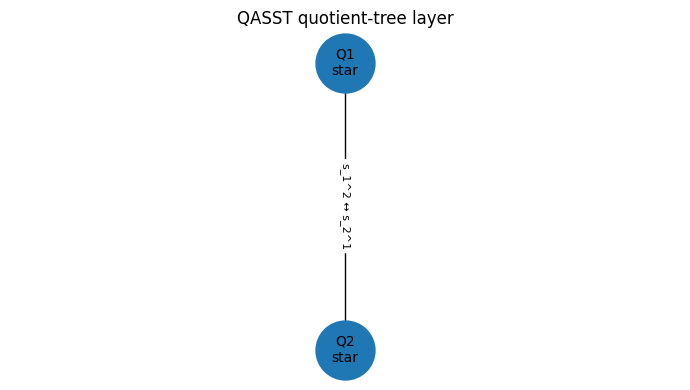

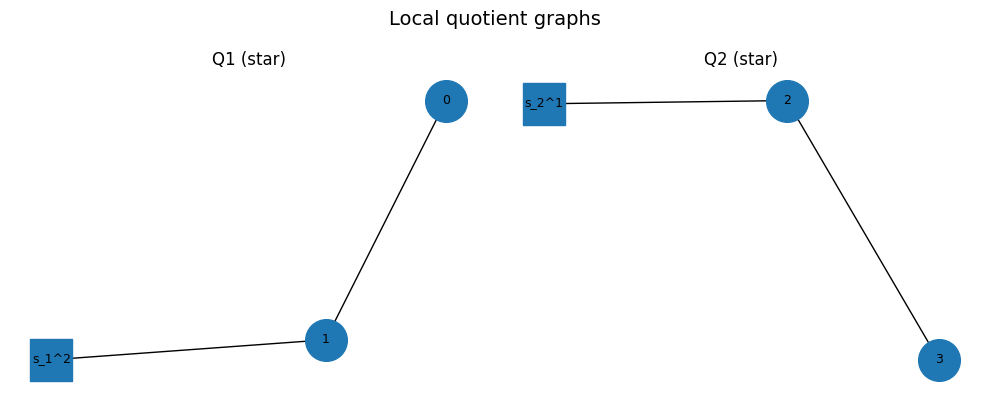

<Figure size 1100x700 with 0 Axes>

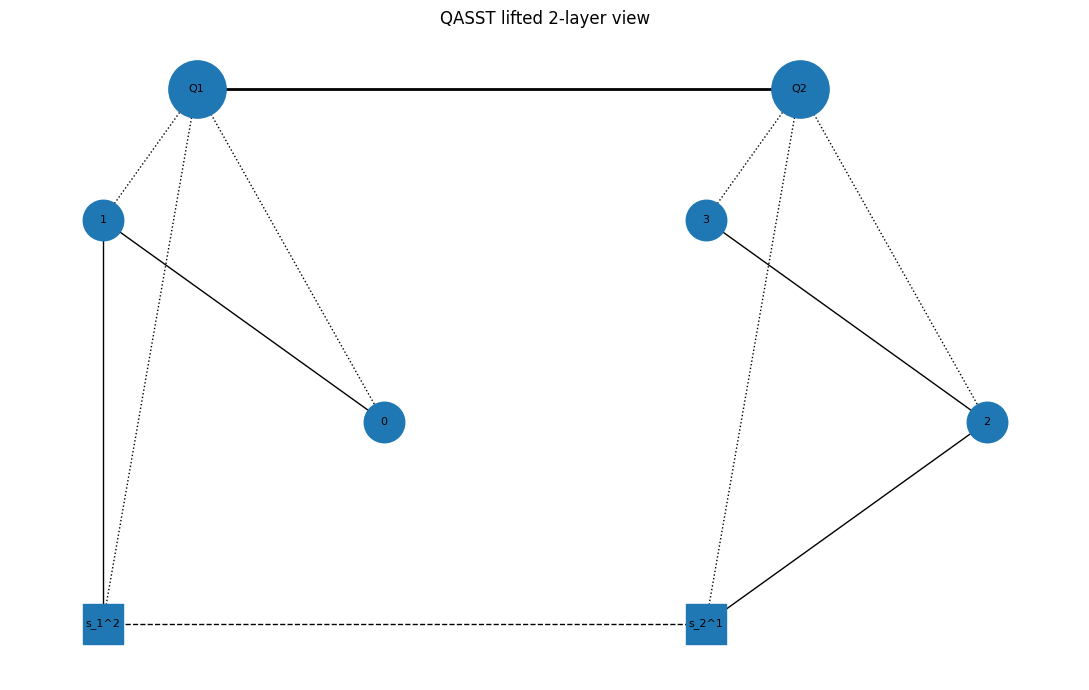

In [40]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.path_graph(4)

qasst = build_qasst(G)
validate_qasst(G, qasst)

layers = qasst_to_two_layer_networkx(qasst)

print("tree nodes:", layers.tree_graph.nodes(data=True))
print("tree edges:", layers.tree_graph.edges(data=True))
print("local quotient ids:", sorted(layers.quotient_graphs.keys()))

show_qasst(qasst)

=== C4 ===
Quotient graphs:
  Q1: type=star
    nodes: [0, 2, s_1^2]
    edges: [(0, s_1^2), (2, s_1^2)]
  Q2: type=star
    nodes: [1, 3, s_2^1]
    edges: [(1, s_2^1), (3, s_2^1)]
Tree edges:
  Q1 -- Q2 via s_1^2 <-> s_2^1


<Figure size 700x400 with 0 Axes>

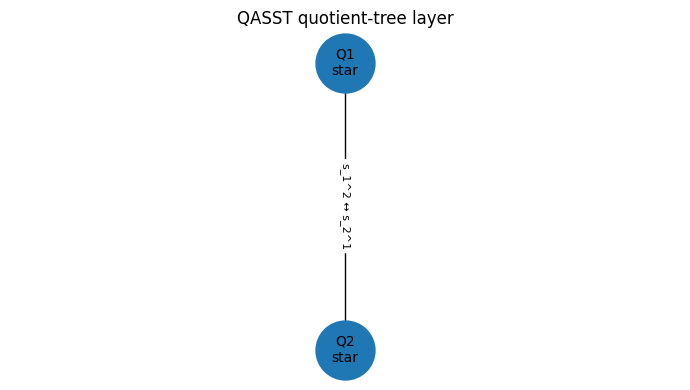

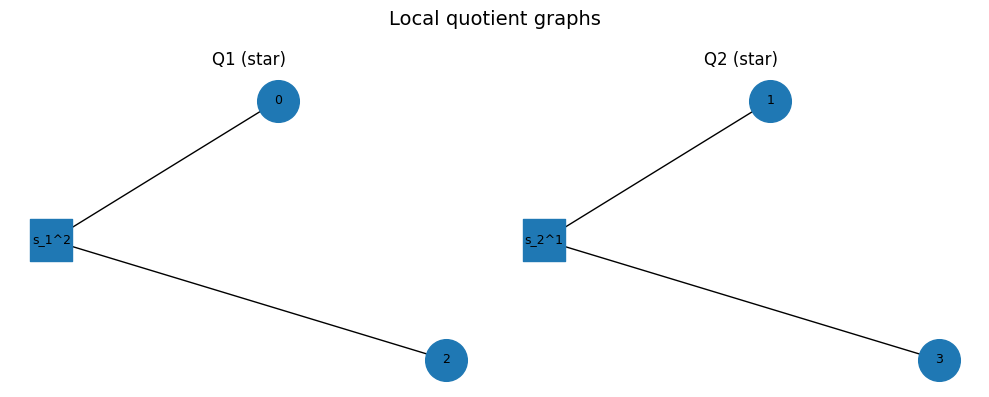

<Figure size 1100x700 with 0 Axes>

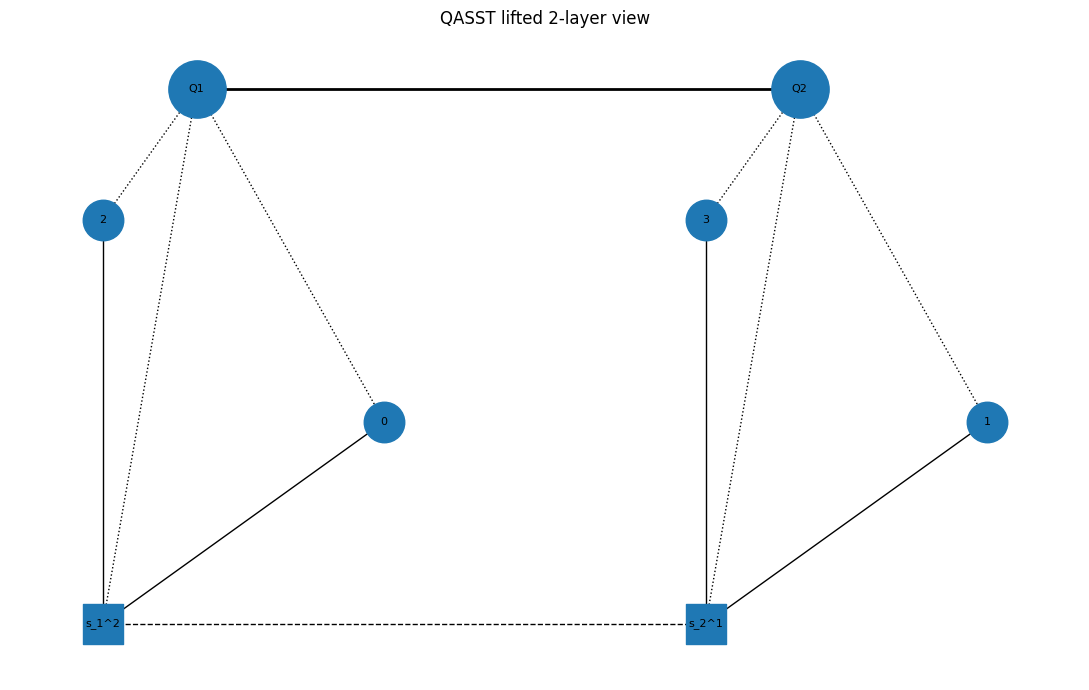

In [41]:
G = nx.cycle_graph(4)
qasst = demo_qasst_on_graph(G, title="C4")

In [42]:
results = exhaustive_validate_range(
    n_values=range(1, 6),
    stop_on_first_failure=False,
    verbose_every=100,
)

print_exhaustive_results(results)

[n=5] checked 100 connected graphs
[n=5] checked 200 connected graphs
[n=5] checked 300 connected graphs
[n=5] checked 400 connected graphs
[n=5] checked 500 connected graphs
[n=5] checked 600 connected graphs
[n=5] checked 700 connected graphs
Exhaustive validation summary
n=1: total=1, connected=1, passed=1, failed=0
n=2: total=2, connected=1, passed=1, failed=0
n=3: total=8, connected=4, passed=4, failed=0
n=4: total=64, connected=38, passed=38, failed=0
n=5: total=1024, connected=728, passed=728, failed=0


In [47]:
result = exhaustive_validate_connected_graphs(
    n=6,
    stop_on_first_failure=True,
    verbose_every=100,
)

print(result)

if result.failures:
    print("first failure:", result.failures[0])

[n=6] checked 100 connected graphs
[n=6] checked 200 connected graphs
[n=6] checked 300 connected graphs
[n=6] checked 400 connected graphs
[n=6] checked 500 connected graphs
[n=6] checked 600 connected graphs
[n=6] checked 700 connected graphs
[n=6] checked 800 connected graphs
[n=6] checked 900 connected graphs
[n=6] checked 1000 connected graphs
[n=6] checked 1100 connected graphs
[n=6] checked 1200 connected graphs
[n=6] checked 1300 connected graphs
[n=6] checked 1400 connected graphs
[n=6] checked 1500 connected graphs
[n=6] checked 1600 connected graphs
[n=6] checked 1700 connected graphs
[n=6] checked 1800 connected graphs
[n=6] checked 1900 connected graphs
[n=6] checked 2000 connected graphs
[n=6] checked 2100 connected graphs
[n=6] checked 2200 connected graphs
[n=6] checked 2300 connected graphs
[n=6] checked 2400 connected graphs
[n=6] checked 2500 connected graphs
[n=6] checked 2600 connected graphs
[n=6] checked 2700 connected graphs
[n=6] checked 2800 connected graphs
[

In [44]:
def exhaustive_validate_connected_graphs_with_examples(
    n: int,
    max_failed_examples: int = 3,
):
    failed_examples = []
    idx = 0

    for G in all_connected_labeled_graphs_on_n(n):
        idx += 1
        try:
            qasst = build_qasst(G)
            validate_qasst(G, qasst)
        except Exception as e:
            failed_examples.append((idx, G.copy(), repr(e)))
            if len(failed_examples) >= max_failed_examples:
                break

    return failed_examples

In [45]:
failed_examples = exhaustive_validate_connected_graphs_with_examples(5)

for idx, G, msg in failed_examples:
    print("failure at connected-index:", idx, msg)
    qasst = build_qasst(G)  # validate は落ちるかもしれないが構築結果は見られる
    show_qasst(qasst)